In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
df = pd.read_csv('/content/drive/MyDrive/CC.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [12]:
data = df.drop('CUST_ID', axis=1)
data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [13]:
data.isna().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [14]:
data_filled = data.fillna(0.000)
data_filled.isna().sum()
data_filled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Scaling using standard scaler

In [15]:
from sklearn.preprocessing import StandardScaler

# Standardize features (important for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filled)
data_scaled = pd.DataFrame(X_scaled, columns=data.columns, index=data.index)

# Clustering

# K-means / GMM (sweep through k values)

In [33]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Range of clusters to try
k_range = np.arange(2, 20 + 1)

silhouette_scores_kmeans = []
silhouette_scores_gmm = []
aic_scores_gmm = []
bic_scores_gmm = []

for k in k_range:
    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_kmeans = kmeans.fit_predict(data_scaled)
    score_kmeans = silhouette_score(data_scaled, labels_kmeans)
    silhouette_scores_kmeans.append(score_kmeans)

    # GMM
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data_scaled)
    labels_gmm = gmm.predict(data_scaled)
    score_gmm = silhouette_score(data_scaled, labels_gmm)
    silhouette_scores_gmm.append(score_gmm)
    aic_scores_gmm.append(gmm.aic(data_scaled))
    bic_scores_gmm.append(gmm.bic(data_scaled))

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


# Silhouette + AIC / BIC

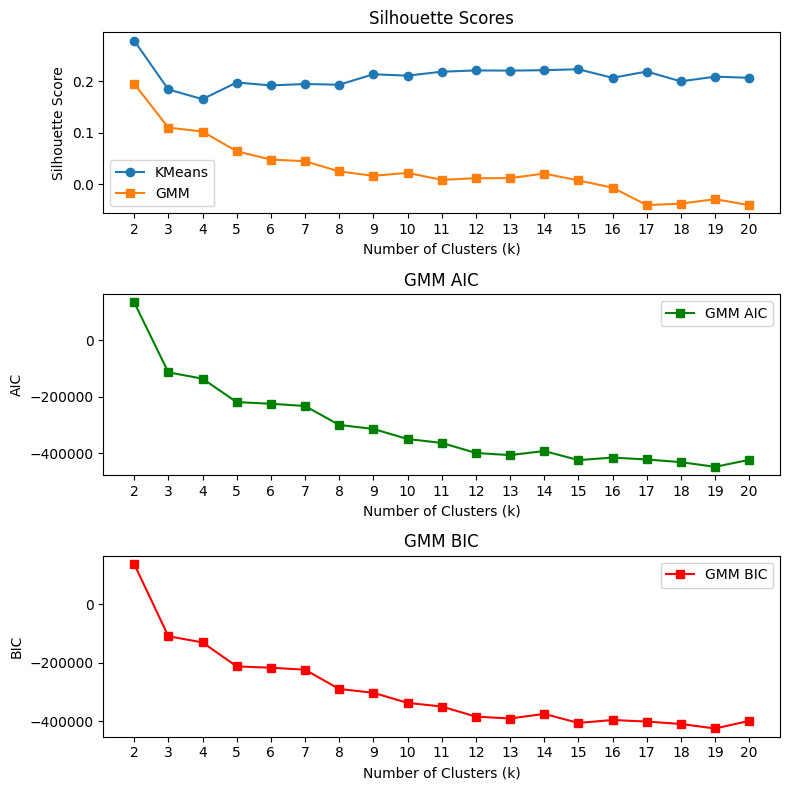

In [34]:
# Plot all stacked vertically
plt.figure(figsize=(8, 8))

# Silhouette scores
plt.subplot(3, 1, 1)
plt.plot(k_range, silhouette_scores_kmeans, marker='o', label='KMeans')
plt.plot(k_range, silhouette_scores_gmm, marker='s', label='GMM')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.legend()

# AIC
plt.subplot(3, 1, 2)
plt.plot(k_range, aic_scores_gmm, marker='s', color='green', label='GMM AIC')
plt.title('GMM AIC')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('AIC')
plt.xticks(k_range)
plt.legend()

# BIC
plt.subplot(3, 1, 3)
plt.plot(k_range, bic_scores_gmm, marker='s', color='red', label='GMM BIC')
plt.title('GMM BIC')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('BIC')
plt.xticks(k_range)
plt.legend()

plt.tight_layout()
plt.show()

Evaluation of clustering explained

*   Silhouette score (higher score aree better indicating well separated clusters, both K-means and GMM show similar trend peaking around 2 or 3 and then decreeasing. Silhouette score was initially higher for k.
*   Akaike information criterion (lower AIC inidciate a bettwe model, AIC decrease as k increeased

*  Bayesian information criterion decreased as numnber of cluster k increased

k=2 and k = 3 could be a choice for GMM based on the sudden drop in AIC.






KMeans Cluster 0 mean silhouette: 0.048
KMeans Cluster 1 mean silhouette: 0.340


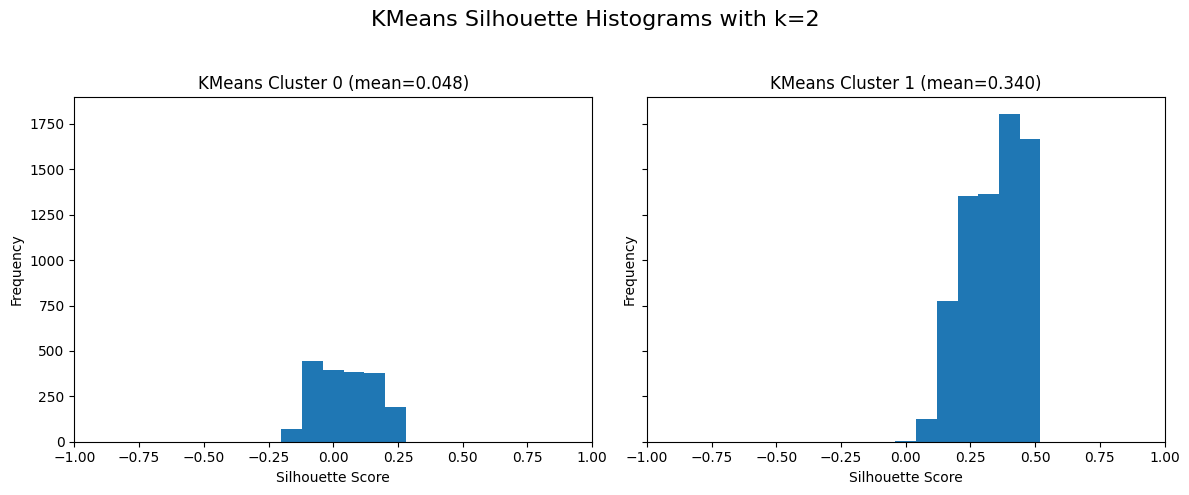

GMM Cluster 0 mean silhouette: -0.072
GMM Cluster 1 mean silhouette: 0.336


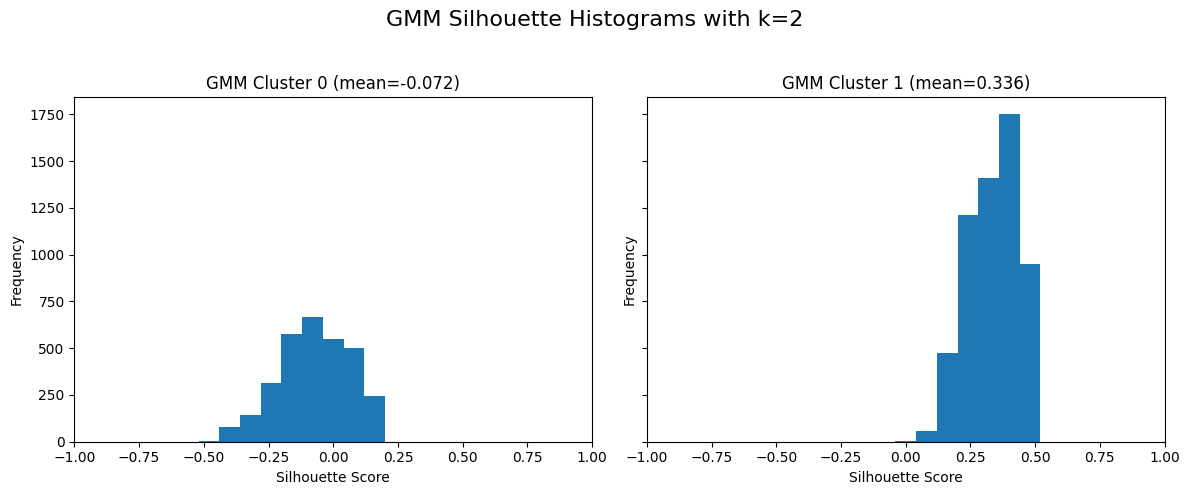

In [35]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# Number of clusters
n_clusters = 2

# Fit KMeans with 2 clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(data_scaled)

# Fit GMM with 2 components
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
labels_gmm = gmm.fit_predict(data_scaled)

# Compute silhouette samples
sil_vals_kmeans = silhouette_samples(data_scaled, labels_kmeans)
sil_vals_gmm = silhouette_samples(data_scaled, labels_gmm)

# === KMeans Histograms: side by side ===
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5), sharey=True)

for i in range(n_clusters):
    ax = axes[i]
    cluster_sil_vals = sil_vals_kmeans[labels_kmeans == i]
    mean_sil = cluster_sil_vals.mean()
    print(f"KMeans Cluster {i} mean silhouette: {mean_sil:.3f}")
    ax.hist(cluster_sil_vals, bins=25, range=(-1, 1) )
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Silhouette Score')
    ax.set_ylabel('Frequency')
    ax.set_title(f'KMeans Cluster {i} (mean={mean_sil:.3f})')

plt.suptitle(f'KMeans Silhouette Histograms with k={n_clusters}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === GMM Histograms: side by side ===
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5), sharey=True)

for i in range(n_clusters):
    ax = axes[i]
    cluster_sil_vals = sil_vals_gmm[labels_gmm == i]
    mean_sil = cluster_sil_vals.mean()
    print(f"GMM Cluster {i} mean silhouette: {mean_sil:.3f}")
    ax.hist(cluster_sil_vals, bins=25, range=(-1, 1) )
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Silhouette Score')
    ax.set_ylabel('Frequency')
    ax.set_title(f'GMM Cluster {i} (mean={mean_sil:.3f})')

plt.suptitle(f'GMM Silhouette Histograms with k={n_clusters}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

For n_cluster=2 both K-Means and GMM were analyzed.

*   KMeans Cluster 0 mean had a a silhouette score of 0.048
*   KMeans Cluster 1 mean had a silhouettee score of 0.340

Cluster 1 has a much higher silhouettee score indicating it is much better separated and more cohesive than cluster 0

GMM Silhouette Histogram

*    GMM Cluster 0 mean had a a silhouette score of -0.072
*    GMM Cluster 0 mean had a a silhouette score of 0.336

GMM Cluster 1 shows a good silhouette score while cluster 0 has a negative meean which indicate cluster might bee misassigned and is not performing ideally.

# Crosstab

In [36]:
# Create a DataFrame to hold both sets of labels
df_labels = pd.DataFrame({
    'kmeans': labels_kmeans,
    'gmm': labels_gmm
}, index=data_scaled.index)

# Crosstab with margins (adds totals)
ct = pd.crosstab(df_labels['kmeans'], df_labels['gmm'], margins=True)
display(ct)

gmm,0,1,All
kmeans,,,
0,1801,58,1859
1,1279,5812,7091
All,3080,5870,8950


cross tab shows the overlap between Kmeans and GMM labels when both are set to n_clusters=2. Helps undertaand how consistent the two algorithms are grouping the data

### Check Adjusted Rand Index and Mutual Info

Both range from $[-1,1]$ (like silhouette) with closer to 1 being more clustering agreement.

In [37]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Example: compare KMeans and GMM
ari = adjusted_rand_score(labels_kmeans, labels_gmm)
ami = adjusted_mutual_info_score(labels_kmeans, labels_gmm)

print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")

ARI: 0.474
AMI: 0.417


ARI and AMI measure the similarity between two clusterings, ranging from -1 to 1. Where 1 indicates perfect agreemeent. 0.47 and 0.42 suggeest a moderate level of agreement between K-Means and GMM but not a strong one which also reflect the silhouette scores.

# Clustering against numerical feature distribution

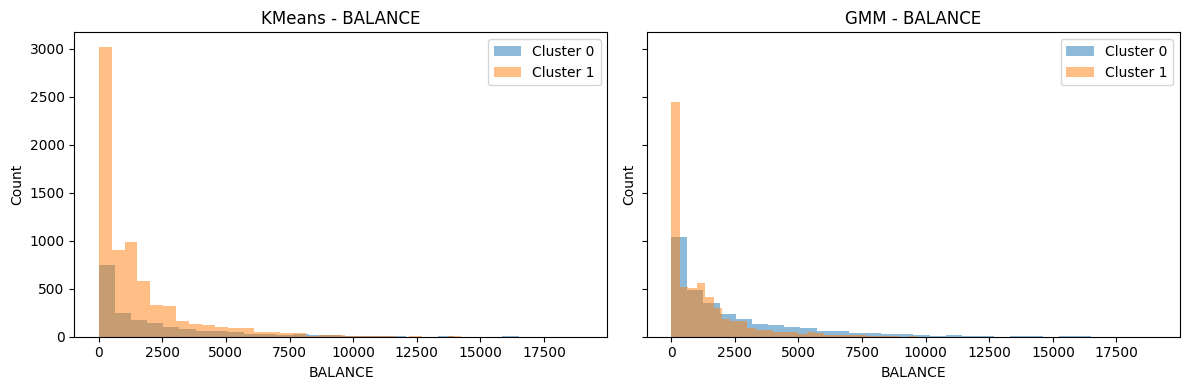

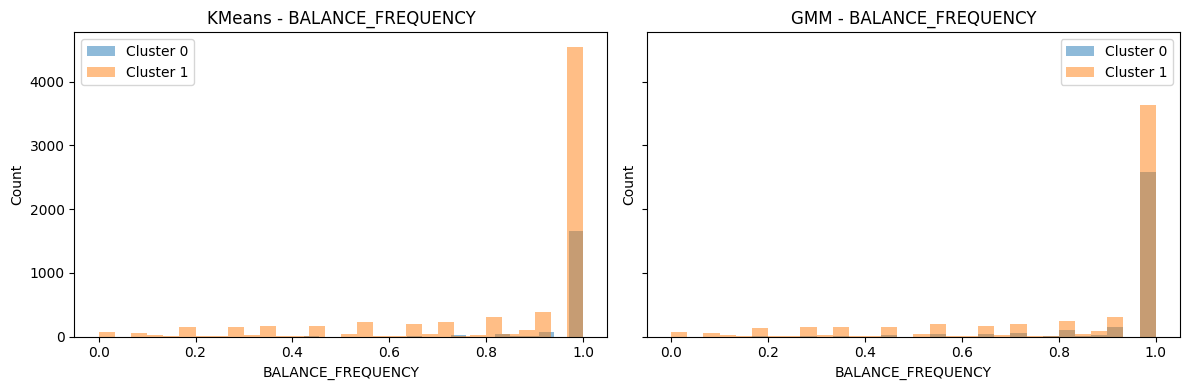

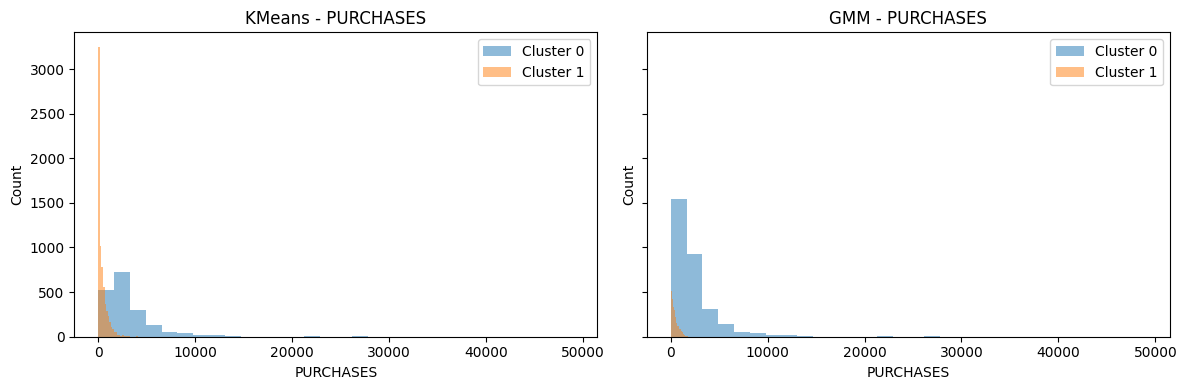

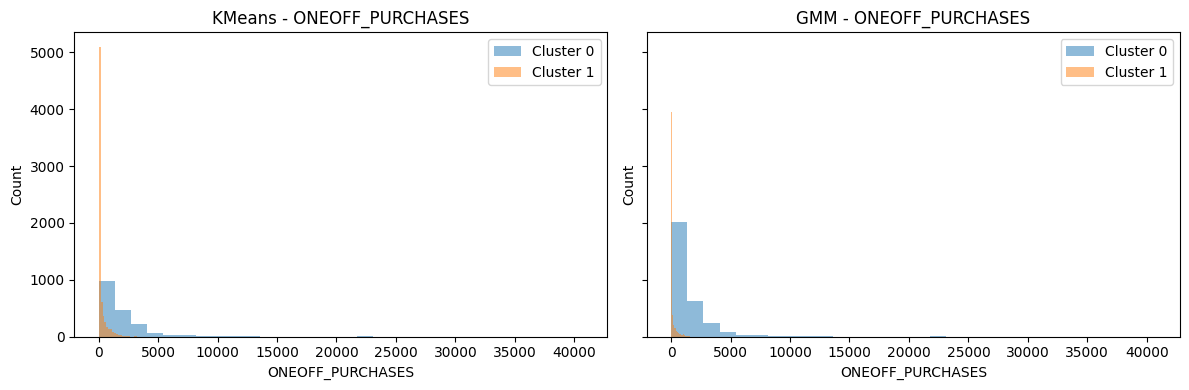

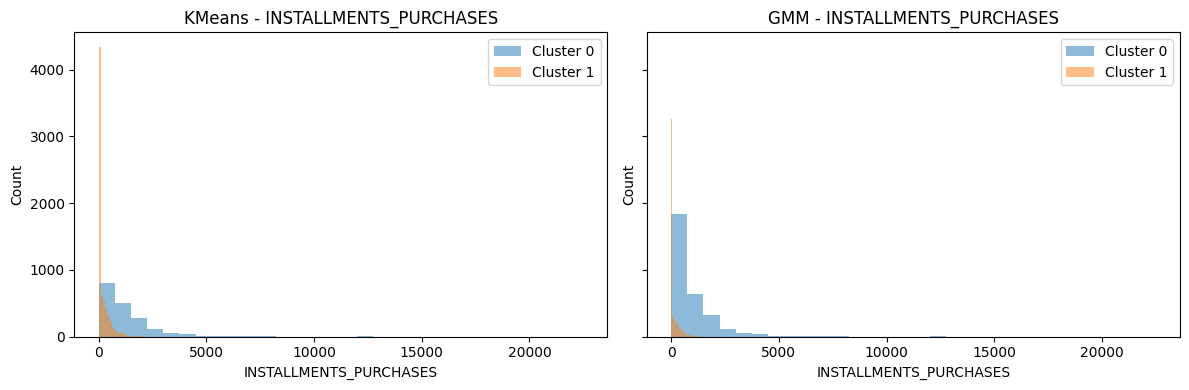

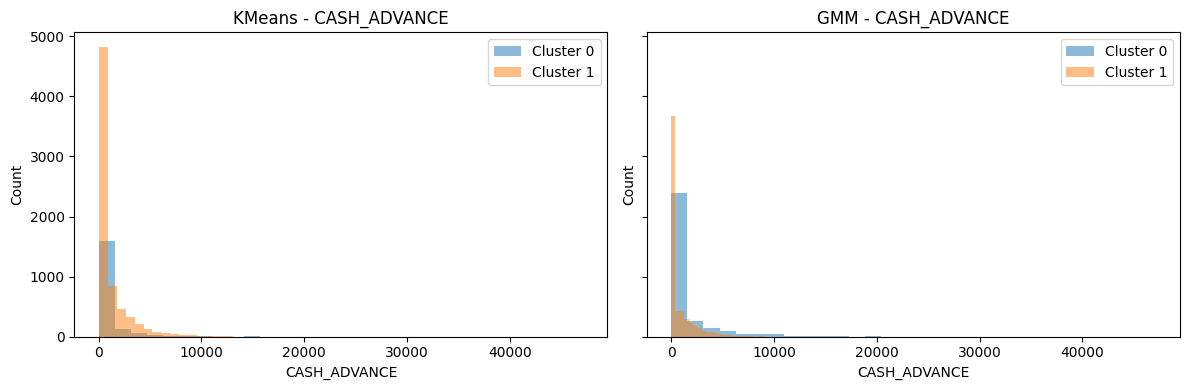

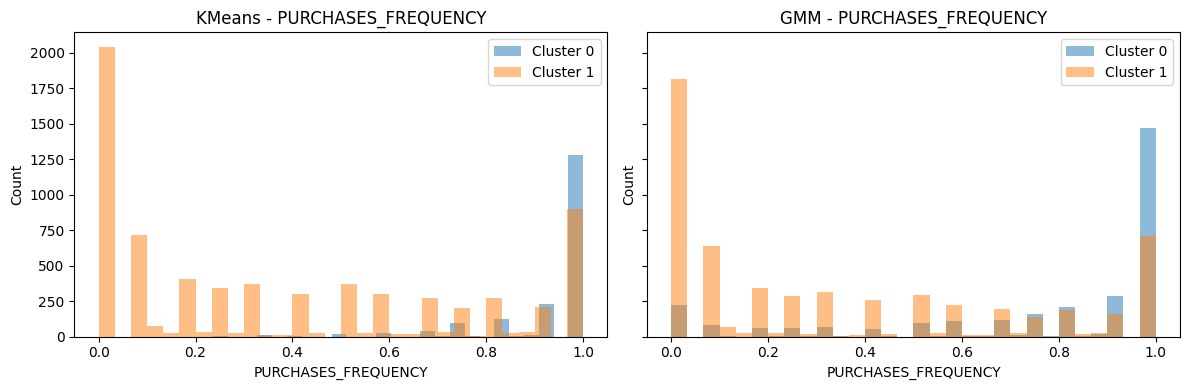

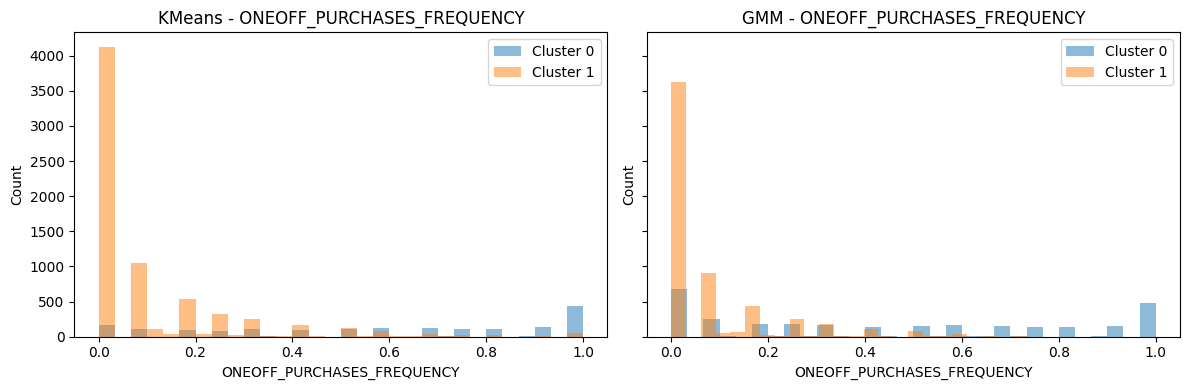

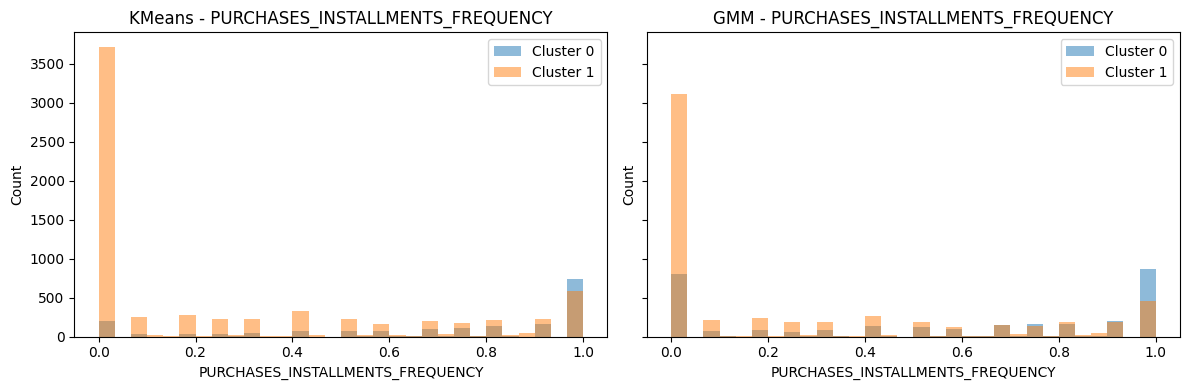

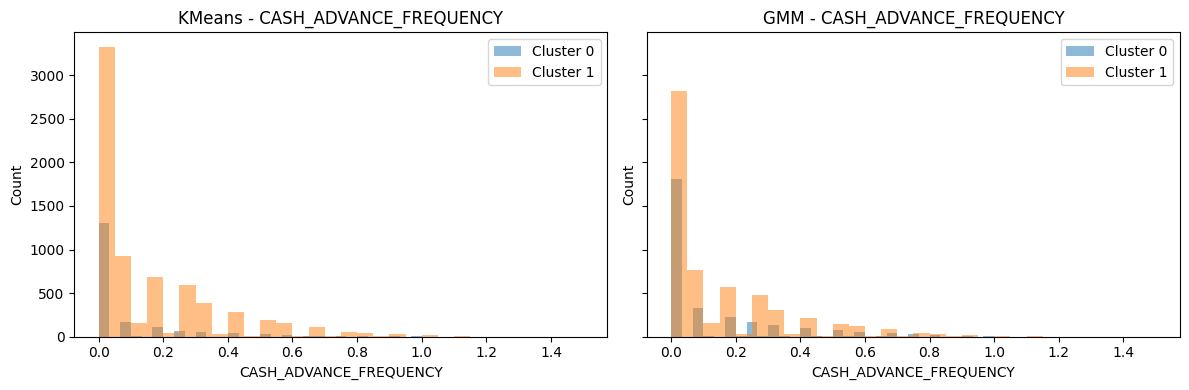

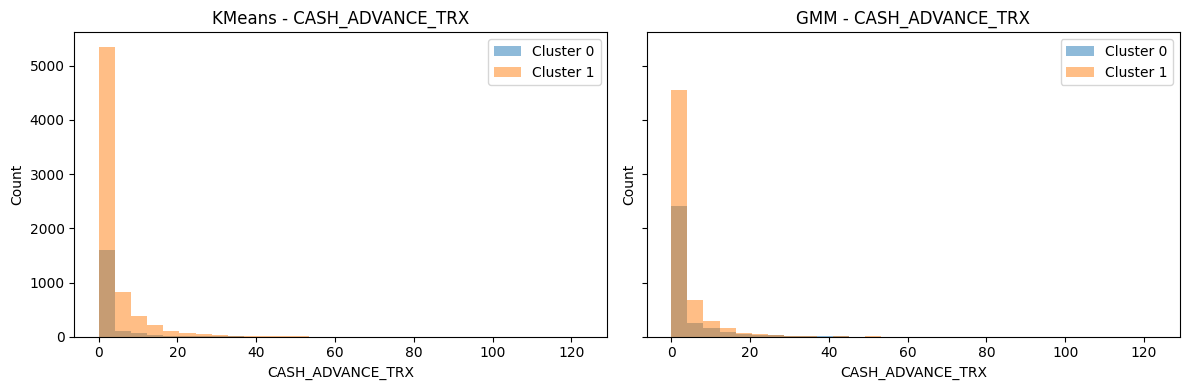

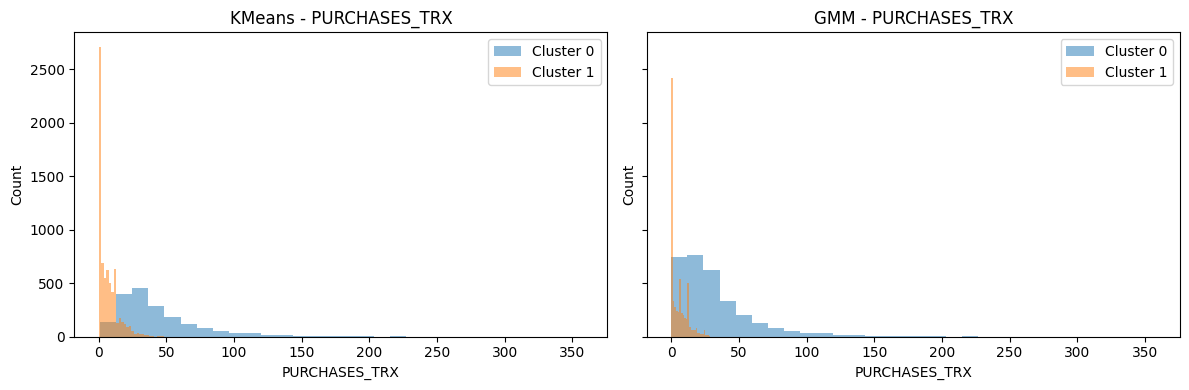

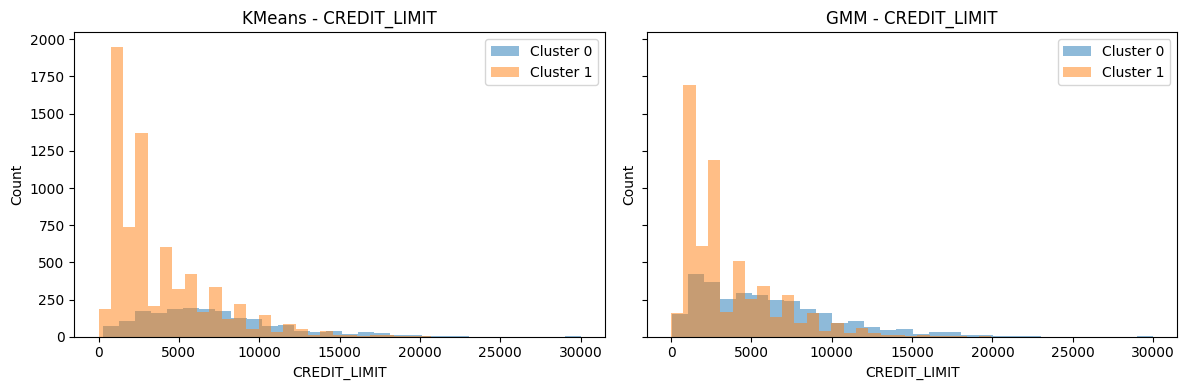

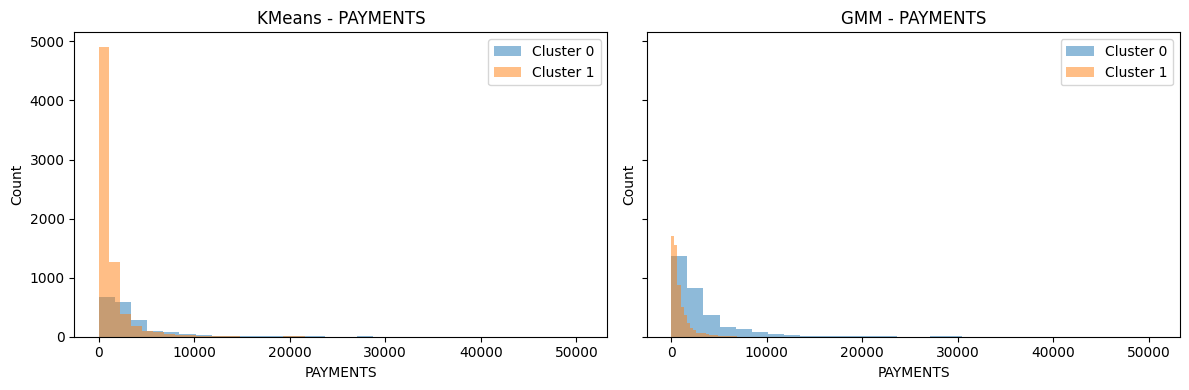

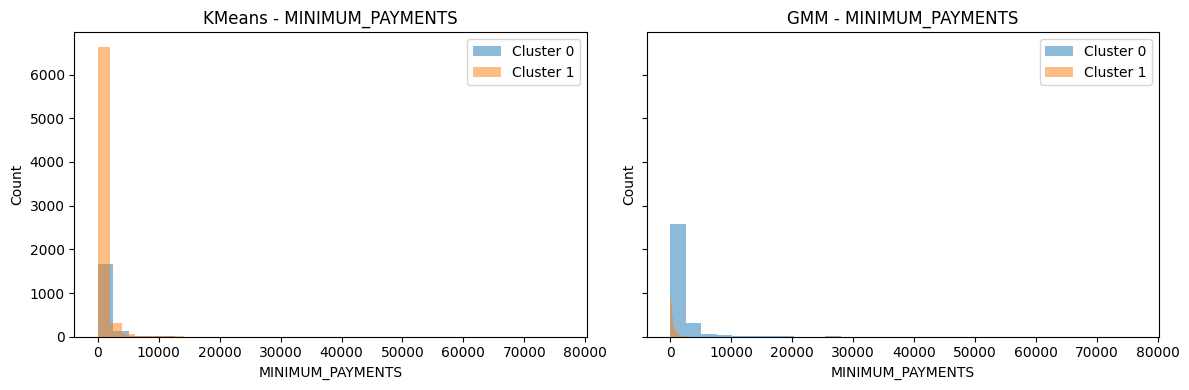

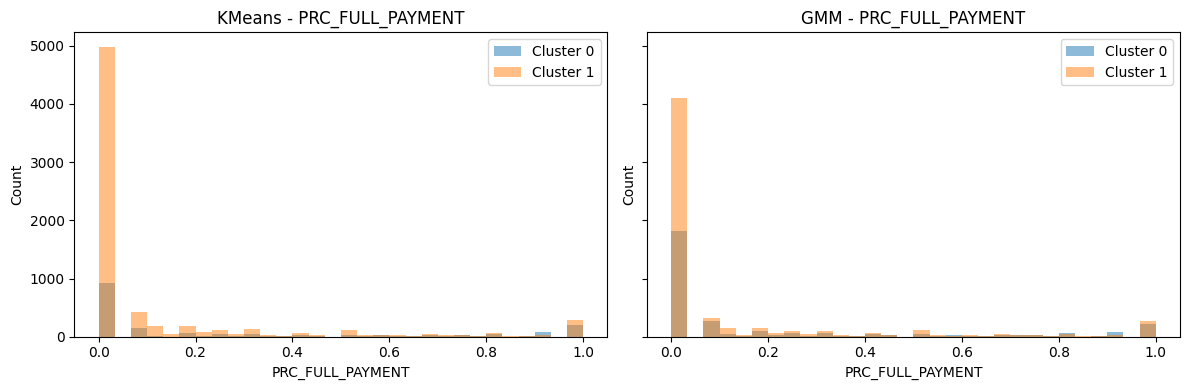

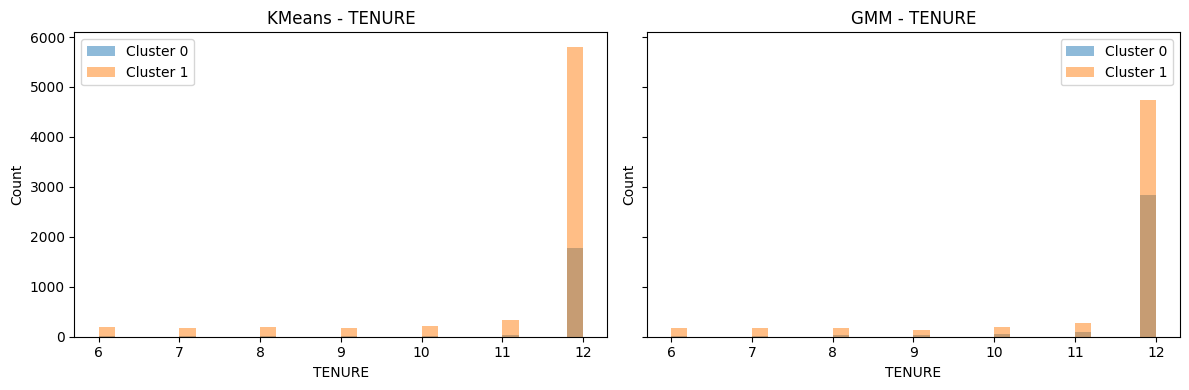

In [38]:
# Loop through each feature
for feature in data_filled.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # KMeans plot
    for label in sorted(df_labels['kmeans'].unique()):
        subset = data_filled[df_labels['kmeans'] == label][feature]
        axes[0].hist(subset, bins=30, alpha=0.5, label=f'Cluster {label}')
    axes[0].set_title(f'KMeans - {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # GMM plot
    for label in sorted(df_labels['gmm'].unique()):
        subset = data_filled[df_labels['gmm'] == label][feature]
        axes[1].hist(subset, bins=30, alpha=0.5, label=f'Cluster {label}')
    axes[1].set_title(f'GMM - {feature}')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Count')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Visualize the distribution of both K-Means and GMM with n_clusters=2.

What to watch out for:

*   If a feature is bimodal (two peaks) it suggest that the cluster could be subdivided or that K-Means/GMM struggled to separate distinct groups basd on that feature

*   If a feature is concntrateed in onee cluster and sparse in another, it indicatees that this feature is a strong discriminatorr between those clusters.

*   Comparring the KMeans and GMM plots for eac feature allows you to understand if they define cluster is based on similar patterns in the data






## t-SNE visualization

t-SNE is a non-linear dimension reduction method that tries to preserves local neighbor relationships in data.

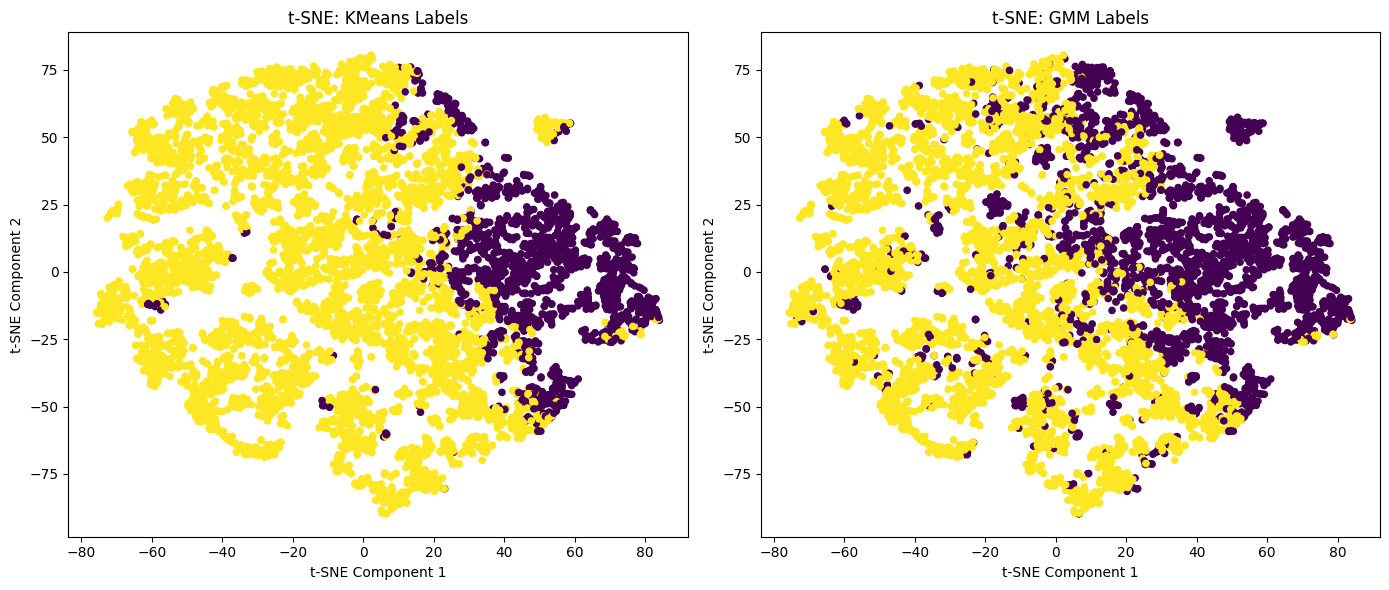

In [39]:
from sklearn.manifold import TSNE

# Perform t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)
X_embedded = tsne.fit_transform(data_scaled)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans plot
axes[0].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_kmeans, s=20, cmap='viridis')
axes[0].set_title('t-SNE: KMeans Labels')
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')

# GMM plot
axes[1].scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_gmm, s=20, cmap='viridis')
axes[1].set_title('t-SNE: GMM Labels')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

t-SNE reeduce data to two dimension for visulaization. Plot help to visually inspect if

Clusters should be close together based on colors.

Cluster structure: If cluster appeaar compact or spread out and if they are outliers or overlapping region

Algorithm differernces: How KMeans and GMM differentiate the data when visualized via slighlty differrent boundariees or point grouped differently

# Agglomerative

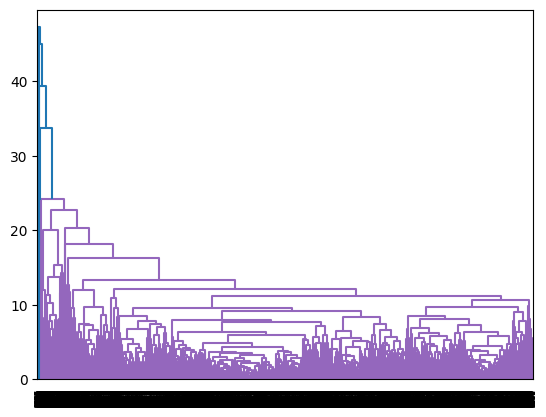

In [41]:
from scipy.cluster.hierarchy import linkage, dendrogram

#link = linkage(data_scaled, method='ward')
link = linkage(data_scaled, method='complete')

dendrogram(link);
plt.show()

In [42]:
from sklearn.cluster import AgglomerativeClustering

# Control
n_clusters = 2

# Agglomerative models using df_num_scaled
model_ward = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_ward = model_ward.fit_predict(data_scaled)

model_complete = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
labels_complete = model_complete.fit_predict(data_scaled)

model_average = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')
labels_average = model_average.fit_predict(data_scaled)

model_single = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
labels_single = model_single.fit_predict(data_scaled)

# Crosstabs vs KMeans labels with named axes
ct_ward = pd.crosstab(
    index=pd.Series(labels_ward, name='ward'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

ct_complete = pd.crosstab(
    index=pd.Series(labels_complete, name='complete'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

ct_average = pd.crosstab(
    index=pd.Series(labels_average, name='average'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

ct_single = pd.crosstab(
    index=pd.Series(labels_single, name='single'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

print("\nWard vs KMeans")
display(ct_ward)

ari = adjusted_rand_score(labels_kmeans, labels_ward)
ami = adjusted_mutual_info_score(labels_kmeans, labels_ward)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")
print()

print("\nComplete vs KMeans")
display(ct_complete)

ari = adjusted_rand_score(labels_kmeans, labels_complete)
ami = adjusted_mutual_info_score(labels_kmeans, labels_complete)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")
print()

print("\nAverage vs KMeans")
display(ct_average)

ari = adjusted_rand_score(labels_kmeans, labels_average)
ami = adjusted_mutual_info_score(labels_kmeans, labels_average)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")
print()

print("\nSingle vs KMeans")
display(ct_single)

ari = adjusted_rand_score(labels_kmeans, labels_single)
ami = adjusted_mutual_info_score(labels_kmeans, labels_single)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")


Ward vs KMeans


kmeans,0,1,All
ward,,,
0,281,5887,6168
1,1578,1204,2782
All,1859,7091,8950


ARI: 0.418
AMI: 0.302


Complete vs KMeans


kmeans,0,1,All
complete,,,
0,1836,7091,8927
1,23,0,23
All,1859,7091,8950


ARI: 0.014
AMI: 0.015


Average vs KMeans


kmeans,0,1,All
average,,,
0,1854,7091,8945
1,5,0,5
All,1859,7091,8950


ARI: 0.003
AMI: 0.003


Single vs KMeans


kmeans,0,1,All
single,,,
0,1858,7091,8949
1,1,0,1
All,1859,7091,8950


ARI: 0.001
AMI: 0.000


Various linkage methods were used for agglomerative clustering that inspected n_cluster=2

Ward vs KMeans


*   ARI of 0.418 and AMI of 0.302.
*   Moderate agreement similar to GMM


Complete vs KMeans

*   ARI of 0.014 and AMI of 0.015.
*   Very low agreement suggesting completee linkage produces a verry different clustering structure compared to K-Means

Average vs KMeans

*   ARI of 0.003 and AMI of 0.003.
*   Essentially no agreement

Single vs KMeans

*   ARI of 0.000 and AMI of 0.000.
*   Essentially no agreement

Ward linkage shows the highest agreement with K-Means, which is expected as both tend to create spherical clusters. Other linkage methods (complete, average, single) produce very different and likely less balanced clusterings for this dataset when compared to K-Means

#Spectral Clustering

In [43]:
from sklearn.cluster import SpectralClustering

# Control
n_clusters = 2

# Spectral Clustering
model_spectral = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',
    n_neighbors=50,
    random_state=42
)
labels_spectral = model_spectral.fit_predict(data_scaled)

# Crosstab: Spectral vs KMeans
ct_spectral = pd.crosstab(
    index=pd.Series(labels_spectral, name='spectral'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

print("\nSpectral vs KMeans")
display(ct_spectral)

# Agreement scores
ari = adjusted_rand_score(labels_kmeans, labels_spectral)
ami = adjusted_mutual_info_score(labels_kmeans, labels_spectral)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")


Spectral vs KMeans


kmeans,0,1,All
spectral,,,
0,1716,2688,4404
1,143,4403,4546
All,1859,7091,8950


ARI: 0.135
AMI: 0.184


Spectral clustering is good for non-globularr clusters and have a differrent structure in the data thaan K-Means which assume spherical clusters

ARI of 0.135 and AMI of 0.184

# Mean shift

In [44]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# Estimate bandwidth
bandwidth = estimate_bandwidth(data_scaled, quantile=0.2)
bandwidth = 4
print(f"Estimated bandwidth: {bandwidth:.3f}")

# MeanShift with estimated bandwidth
model_meanshift = MeanShift(bandwidth=bandwidth, cluster_all=False)
labels_meanshift = model_meanshift.fit_predict(data_scaled)

# Crosstab: MeanShift vs KMeans
ct_meanshift = pd.crosstab(
    index=pd.Series(labels_meanshift, name='meanshift'),
    columns=pd.Series(labels_kmeans, name='kmeans'),
    margins=True
)

print("\nMeanShift vs KMeans")
display(ct_meanshift)

# Agreement scores
ari = adjusted_rand_score(labels_kmeans, labels_meanshift)
ami = adjusted_mutual_info_score(labels_kmeans, labels_meanshift)
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")

Estimated bandwidth: 4.000

MeanShift vs KMeans


kmeans,0,1,All
meanshift,,,
-1,1070,1306,2376
0,704,5764,6468
1,0,4,4
2,0,4,4
3,3,0,3
...,...,...,...
85,1,0,1
86,1,0,1
87,1,0,1


ARI: 0.251
AMI: 0.125


Estimate bandwith suggest an optimal bandwith.

Meanshift vs KMeans have a low agreeement . Meanshift does not reequire specifying the number of clusters beforehand but find them based on density. The agreement with K-Means suggestthe desnity based clusters are some what differrent from centroid based clusters

#Density-Based Spatial Clustering of Application with Noise

,-1,0,1,2,3,4,5,6,7,8,...,19,20,21,22,23,24,25,26,27,28
count,8322,70,149,56,18,71,25,19,21,43,...,7,8,5,5,5,10,5,5,5,5


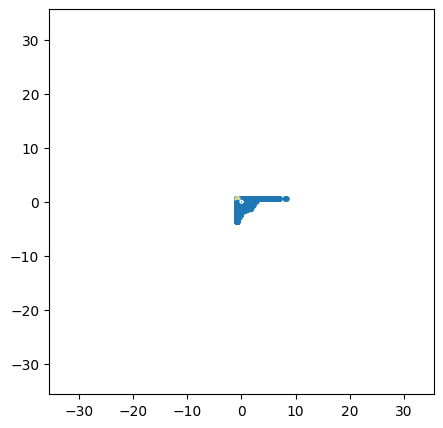

In [19]:
from sklearn.cluster import DBSCAN

radius      = 0.25
min_samples = 5

# Find clusters
model = DBSCAN(
    eps=radius,
    min_samples=min_samples
)
labels = model.fit_predict(data_scaled)

display(pd.DataFrame(pd.Series(labels).value_counts().sort_index()).T)

# Plot
cmap = 'tab20'

plt.figure(figsize=(5,5))

theta = np.linspace(0,2*np.pi,100)
c = radius * np.cos(theta)
s = radius * np.sin(theta)

plt.plot(c, s, linewidth=1, c='w')

# Define MAX_VAL for plot limits
MAX_VAL = np.abs(data_scaled.values).max() * 1.1

# Use .iloc for DataFrame column access
plt.scatter(data_scaled.iloc[:,0], data_scaled.iloc[:,1], c=labels, s=10, cmap=cmap);
plt.xlim(-MAX_VAL,MAX_VAL)
plt.ylim(-MAX_VAL,MAX_VAL)
plt.gca().set_aspect('equal')
plt.show()

# Changing the DBSCAN radius

radius: 0.01


,-1
count,8950


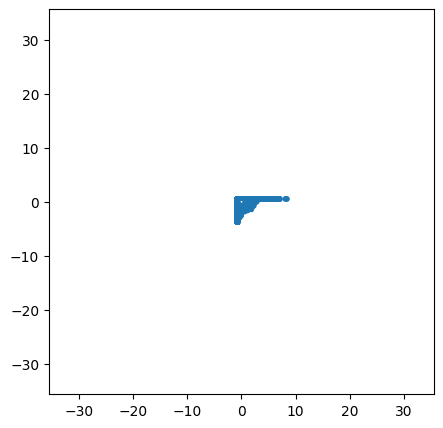

radius: 0.12945191929821756


,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
count,8741,7,74,34,10,7,5,8,7,17,7,9,5,5,5,4,5


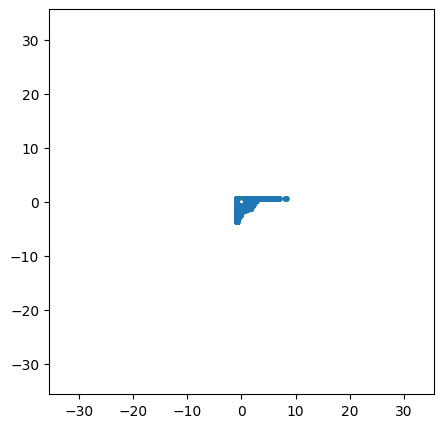

radius: 0.2489038385964351


,-1,0,1,2,3,4,5,6,7,8,...,18,19,20,21,22,23,24,25,26,27
count,8327,70,149,56,18,71,25,19,21,43,...,5,7,8,5,5,5,10,5,5,5


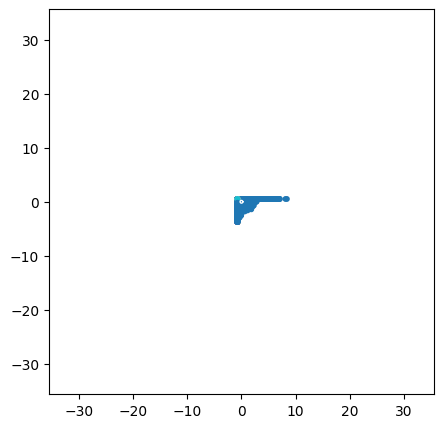

radius: 0.3683557578946527


,-1,0,1,2,3,4,5,6,7,8,...,33,34,35,36,37,38,39,40,41,42
count,7645,238,233,229,18,43,144,16,36,14,...,5,10,6,4,5,4,5,5,5,5


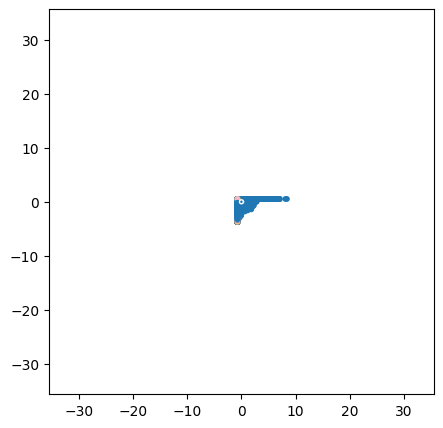

radius: 0.4878076771928702


,-1,0,1,2,3,4,5,6,7,8,...,27,28,29,30,31,32,33,34,35,36
count,6702,1650,8,5,6,242,7,9,24,14,...,8,7,5,10,4,6,5,5,3,5


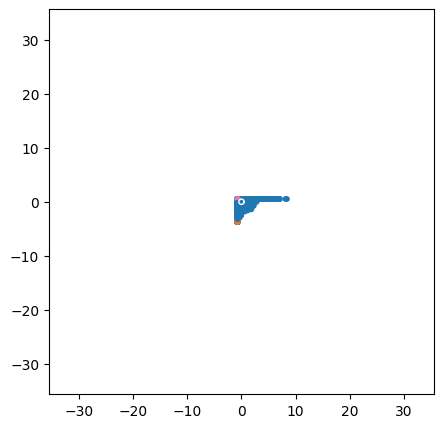

radius: 0.6072595964910877


,-1,0,1,2,3,4,5,6,7,8,...,22,23,24,25,26,27,28,29,30,31
count,5738,2928,10,6,32,6,3,30,16,8,...,5,5,4,10,6,5,5,6,5,6


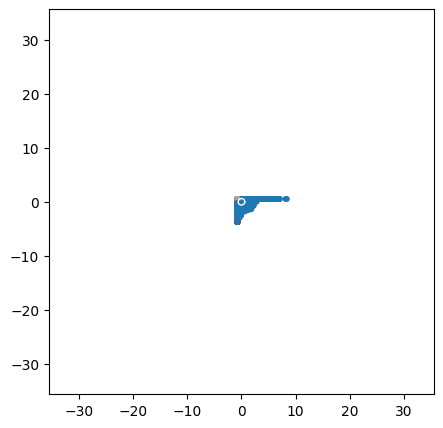

radius: 0.7267115157893054


,-1,0,1,2,3,4,5,6,7,8,...,17,18,19,20,21,22,23,24,25,26
count,4926,3774,23,6,5,45,26,6,7,5,...,9,8,10,5,6,5,6,5,5,5


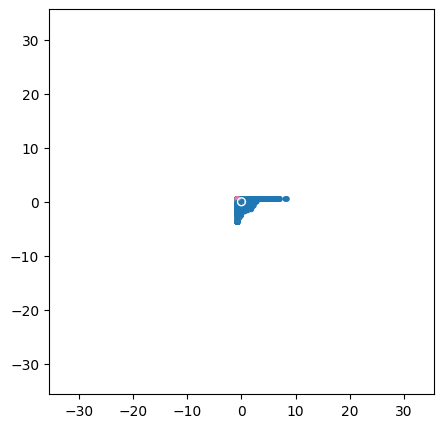

radius: 0.8461634350875229


,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
count,4068,4771,6,30,9,9,5,4,6,3,5,5,5,6,7,6,5


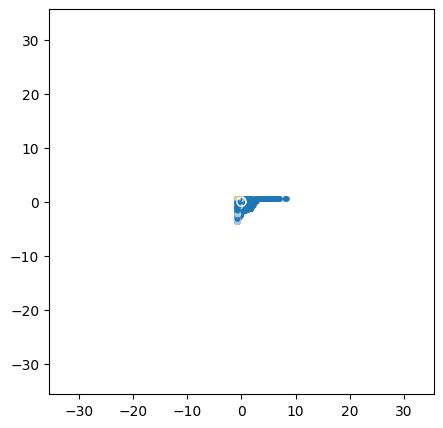

radius: 0.9656153543857404


,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
count,3281,5568,24,4,4,4,4,7,4,7,4,5,5,5,5,6,4,4,5


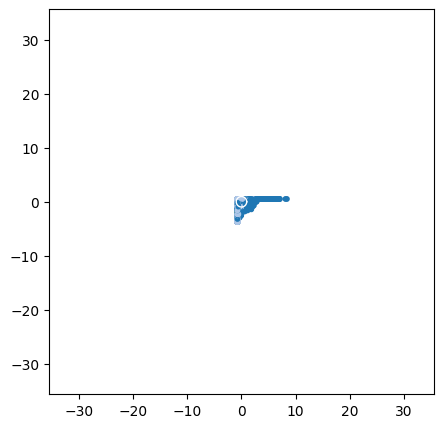

radius: 1.085067273683958


,-1,0,1,2,3,4,5,6,7,8,9
count,2630,6277,7,6,5,4,6,5,5,3,2


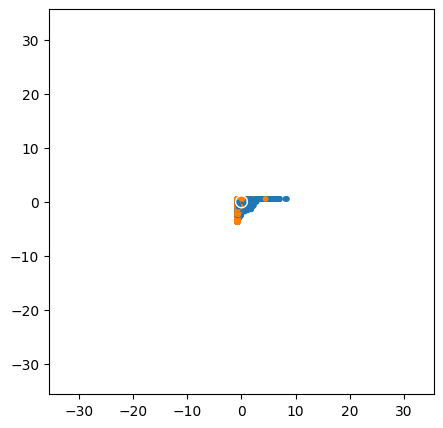

radius: 1.2045191929821755


,-1,0,1,2,3,4,5,6
count,2150,6761,17,4,4,5,5,4


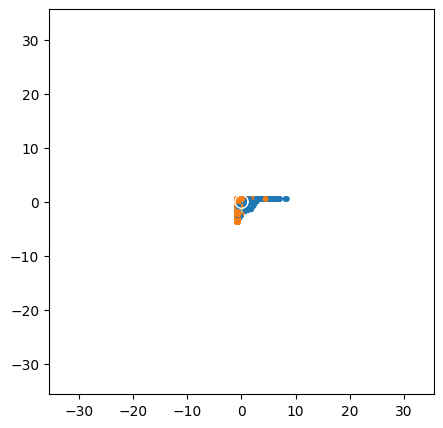

radius: 1.323971112280393


,-1,0,1,2,3,4,5,6
count,1735,7181,9,5,6,4,5,5


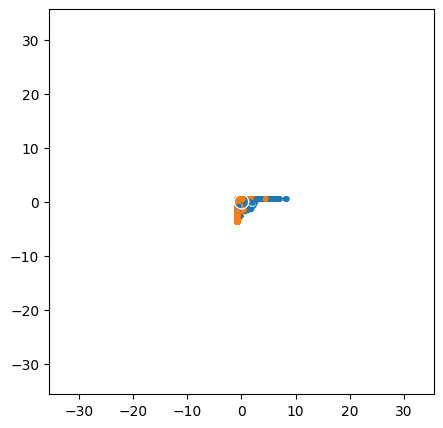

radius: 1.4434230315786107


,-1,0,1,2
count,1445,7495,5,5


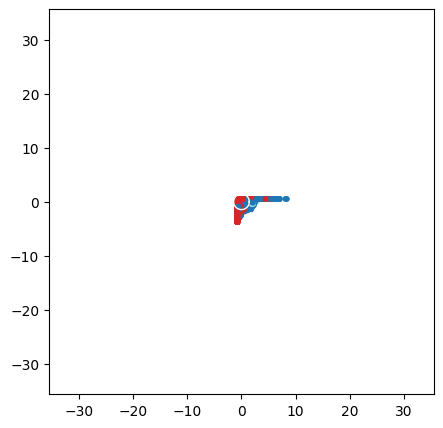

radius: 1.5628749508768283


,-1,0,1,2,3,4,5
count,1190,7734,5,6,4,5,6


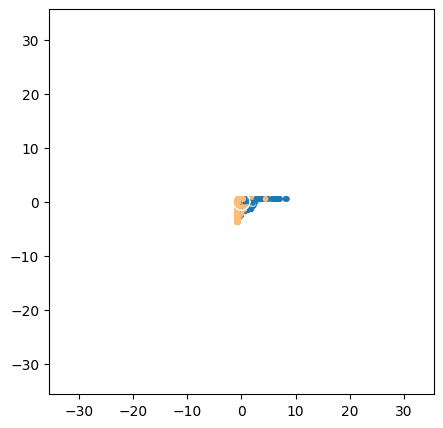

radius: 1.6823268701750458


,-1,0
count,999,7951


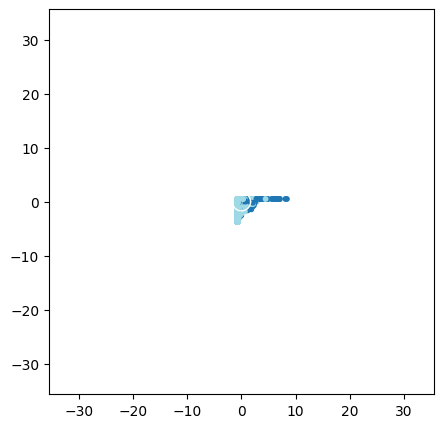

radius: 1.8017787894732633


,-1,0,1
count,817,8128,5


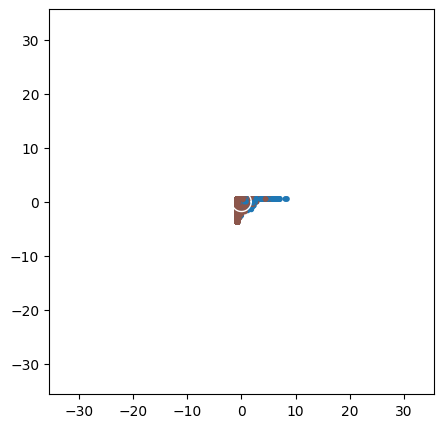

radius: 1.9212307087714808


,-1,0
count,679,8271


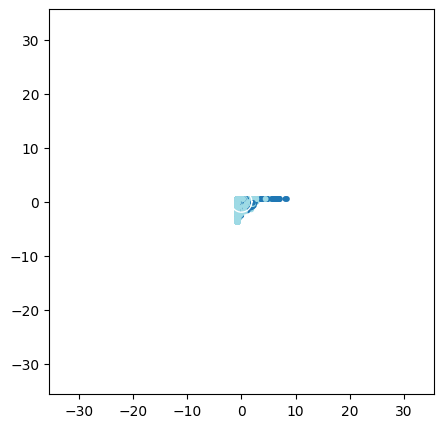

radius: 2.0406826280696984


,-1,0,1
count,571,8374,5


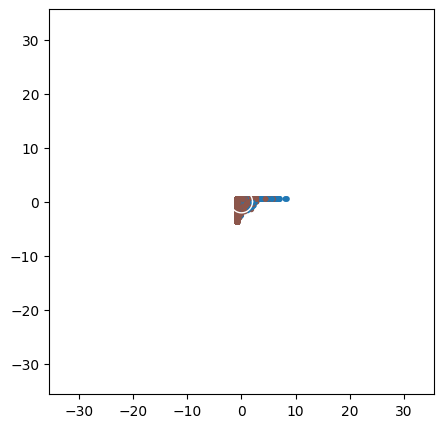

radius: 2.1601345473679157


,-1,0,1,2
count,489,8450,7,4


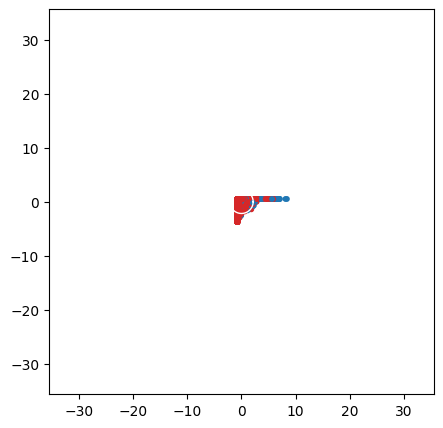

radius: 2.2795864666661334


,-1,0
count,427,8523


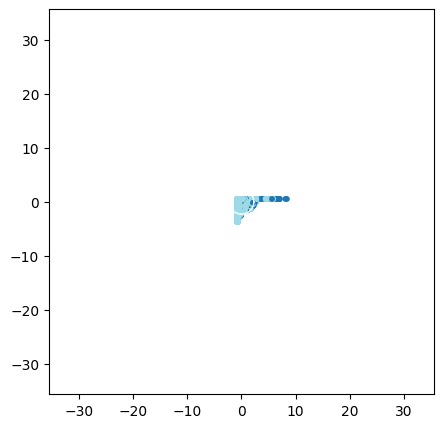

radius: 2.3990383859643507


,-1,0
count,374,8576


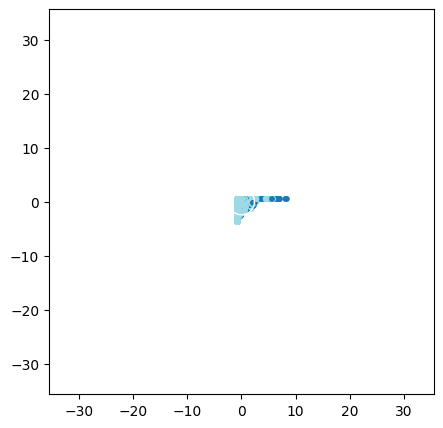

radius: 2.5184903052625685


,-1,0
count,337,8613


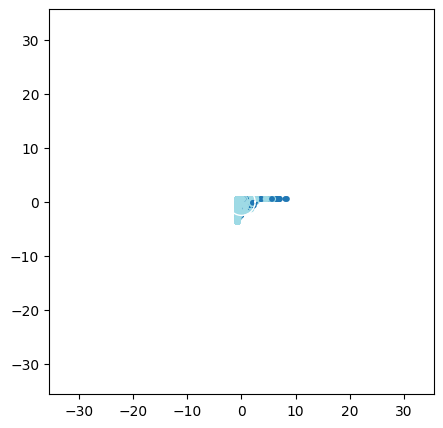

radius: 2.6379422245607858


,-1,0
count,299,8651


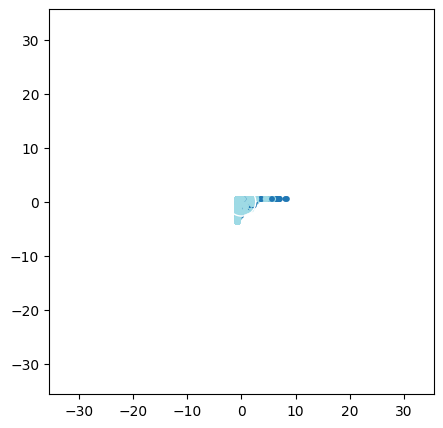

radius: 2.7573941438590035


,-1,0,1
count,257,8689,4


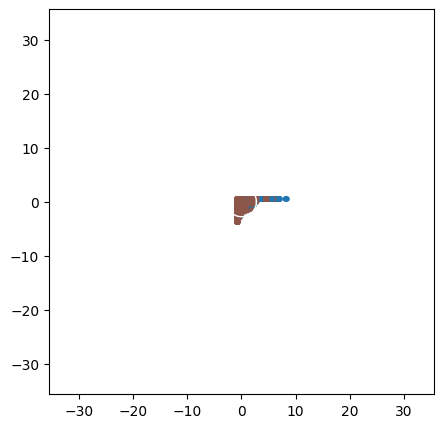

radius: 2.8768460631572212


,-1,0
count,229,8721


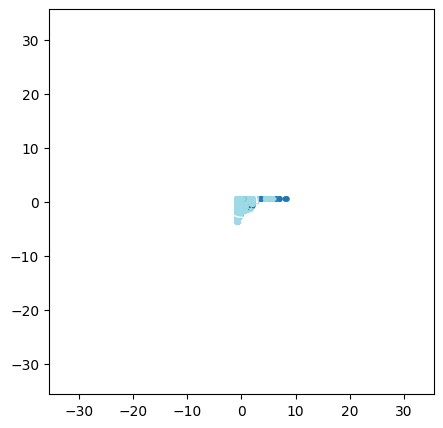

radius: 2.9962979824554385


,-1,0
count,211,8739


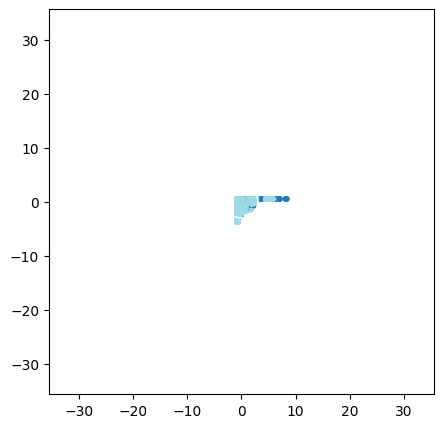

radius: 3.1157499017536563


,-1,0
count,181,8769


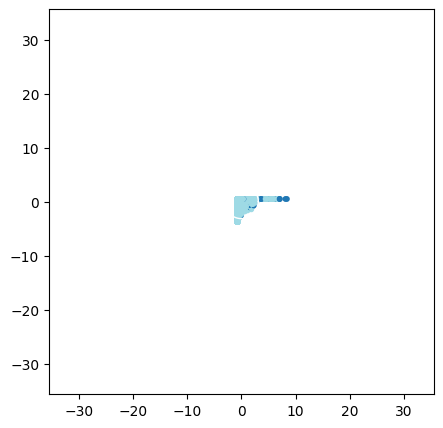

radius: 3.2352018210518736


,-1,0
count,159,8791


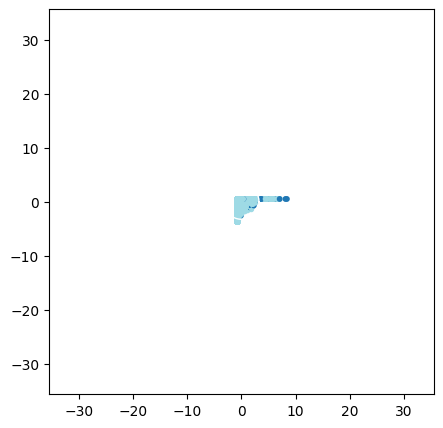

radius: 3.3546537403500913


,-1,0
count,150,8800


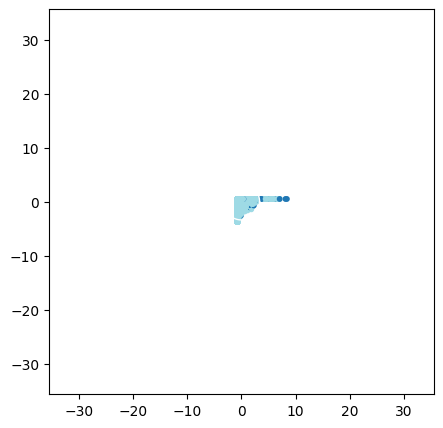

radius: 3.4741056596483086


,-1,0
count,138,8812


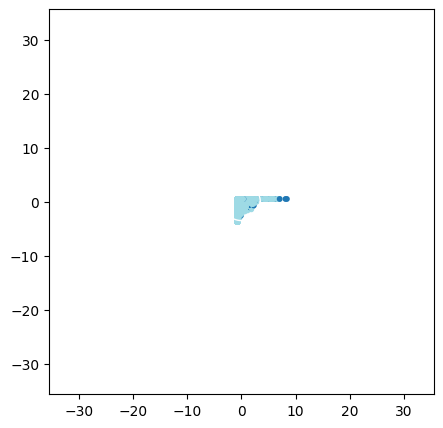

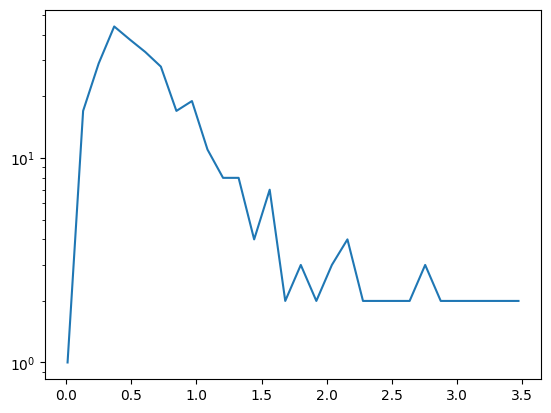

In [23]:
from sklearn.cluster import estimate_bandwidth

radii = np.linspace(
    0.01,
    estimate_bandwidth(data_scaled, quantile=0.15),
    30
)

min_samples = 5

n_clusters = []

for r in radii:
    model = DBSCAN(eps=r, min_samples=min_samples)
    labels = model.fit_predict(data_scaled)
    labels = pd.Series(labels)

    vc = labels.value_counts()

    n_clusters.append( vc.shape[0] )

    # treat outliers as separate classes
    """
    try:
        n_clusters.append( vc.shape[0] - 1 + vc[-1] )
    except:
        n_clusters.append( vc.shape[0] )
    # end
    """

    print(f"radius: {r}")
    display(pd.DataFrame(pd.Series(labels).value_counts().sort_index()).T)

    # Plot
    cmap = 'tab20'

    plt.figure(figsize=(5,5))

    theta = np.linspace(0,2*np.pi,100)
    c = r * np.cos(theta)
    s = r * np.sin(theta)

    plt.plot(c, s, linewidth=1, c='w')

    MAX_VAL = np.abs(data_scaled.values).max() * 1.1

    plt.scatter(data_scaled.iloc[:,0], data_scaled.iloc[:,1], c=labels, s=10, cmap=cmap);
    plt.xlim(-MAX_VAL,MAX_VAL)
    plt.ylim(-MAX_VAL,MAX_VAL)
    plt.gca().set_aspect('equal')
    plt.show()

# end

plt.semilogy( radii, n_clusters )
plt.show()

        -1    0    1    2    3    4    5    6    7    8   ...   19   20   21  \
count  8322   70  149   56   18   71   25   19   21   43  ...    7    8    5   

        22   23   24   25   26   27   28  
count    5    5   10    5    5    5    5  

[1 rows x 30 columns]


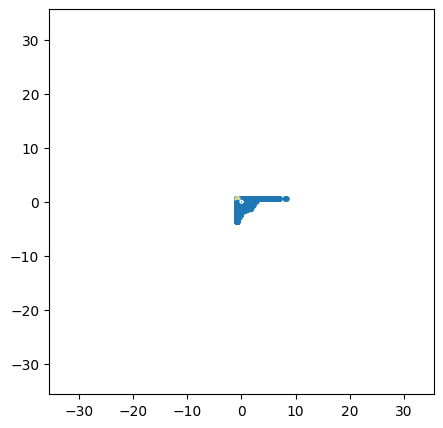

In [25]:
from sklearn.cluster import DBSCAN

# Find clusters
model = DBSCAN(eps=radius, min_samples=5)
labels = model.fit_predict(data_scaled)

print(pd.DataFrame(pd.Series(labels).value_counts().sort_index()).T)

# Plot
plt.figure(figsize=(5,5))

theta = np.linspace(0,2*np.pi,100)
c = radius * np.cos(theta)
s = radius * np.sin(theta)

plt.plot(c, s, linewidth=1, c='w')

# Define MAX_VAL for plot limits
MAX_VAL = np.abs(data_scaled.values).max() * 1.1

# Use .iloc for DataFrame column access
plt.scatter(data_scaled.iloc[:,0], data_scaled.iloc[:,1], c=labels, s=10, cmap=cmap);
plt.xlim(-MAX_VAL,MAX_VAL)
plt.ylim(-MAX_VAL,MAX_VAL)
plt.gca().set_aspect('equal')
plt.show()

Output shows 8322 points are labeled as -1 (noise) for a radiuos of 0.25, the majority are noise only a small cluster were formed (30).

Iteration over different radius was done to minimize the noisee point. The n_clusters shows how many clusters werre found forr each radius

Overall, the analysis shows that k=2 and k=3 are porteenital for K-Means aand GMM based on silhouettee,AIC and BIC. Howeverr GMM had a negative silhouettee scoree for one clusterr with k=2. The agreeement between different clusterring algorithm varries widely with Ward agglomerative clustering showing the highest similarity to K-Means. DBSCAN with a small radius identifieda large numbeer of noise point identifying the data might not be dense eenough in distinct regon.